1. Read, display, and save images using OpenCV. Convert RGB to grayscale and binary.

Saving belgian_blue.jpg to belgian_blue (2).jpg


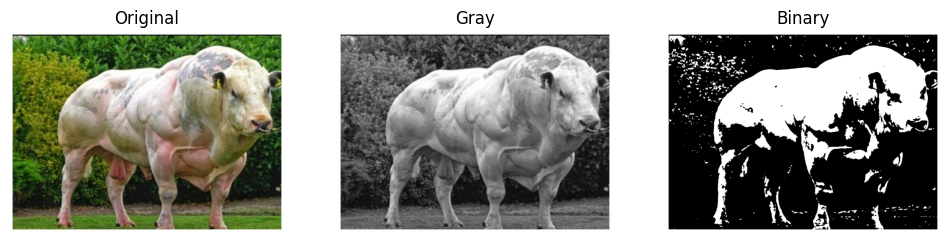

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

f = files.upload()
img = cv2.imread(list(f.keys())[0])

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12,4))
plt.subplot(131), plt.imshow(rgb), plt.title("Original"), plt.axis("off")
plt.subplot(132), plt.imshow(gray, cmap="gray"), plt.title("Gray"), plt.axis("off")
plt.subplot(133), plt.imshow(binary, cmap="gray"), plt.title("Binary"), plt.axis("off")
plt.show()

2. Convert a color image into gray scale and binary without using opencv/library functions.

Saving belgian_blue.jpg to belgian_blue (4).jpg


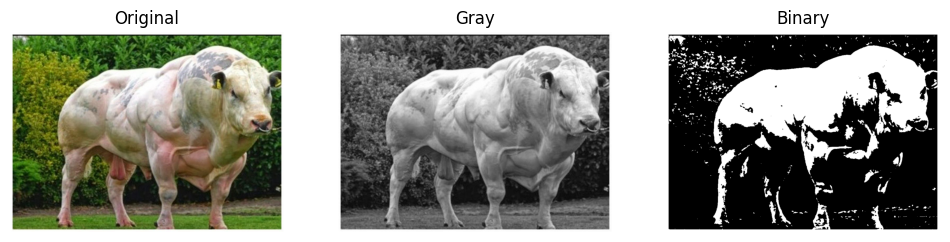

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

f = files.upload()
img = cv2.imread(list(f.keys())[0])

h, w = img.shape[:2]
gray = np.zeros((h, w), dtype=np.uint8)
binary = np.zeros((h, w), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        b, g, r = img[i, j]
        gray[i, j] = 0.299*r + 0.587*g + 0.114*b
        binary[i, j] = 255 if gray[i, j] > 127 else 0

plt.figure(figsize=(12,4))
plt.subplot(131), plt.imshow(img[:,:,::-1]), plt.title("Original"), plt.axis("off")
plt.subplot(132), plt.imshow(gray, cmap="gray"), plt.title("Gray"), plt.axis("off")
plt.subplot(133), plt.imshow(binary, cmap="gray"), plt.title("Binary"), plt.axis("off")
plt.show()

3. Read an image and apply translation, scaling, and rotation transformations using OpenCV.

Saving belgian_blue.jpg to belgian_blue (5).jpg


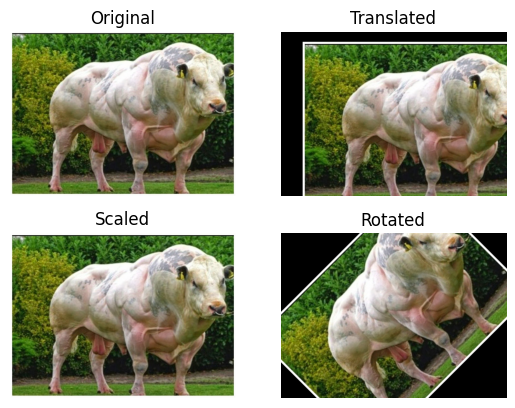

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

f = files.upload()
img = cv2.imread(list(f.keys())[0])

h, w = img.shape[:2]

T = np.float32([[1, 0, 100], [0, 1, 50]])
translated = cv2.warpAffine(img, T, (w, h))

scaled = cv2.resize(img, None, fx=0.5, fy=0.5)

R = cv2.getRotationMatrix2D((w//2, h//2), 45, 1)
rotated = cv2.warpAffine(img, R, (w, h))

titles = ["Original", "Translated", "Scaled", "Rotated"]
images = [img, translated, scaled, rotated]

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i][:,:,::-1])
    plt.title(titles[i])
    plt.axis("off")

plt.show()

4. Create a program to perform addition and subtraction of two images and display the result. (Perform blending by assigning weightages to the images).

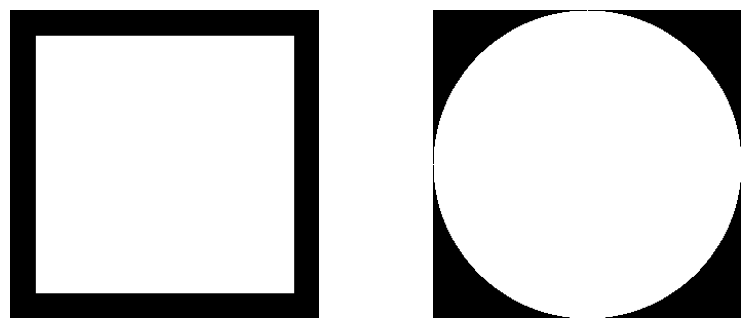

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rectangle = np.zeros((300, 300), dtype=np.uint8)
rectangle[25:276, 25:276] = 255

circle = np.zeros((300, 300), dtype=np.uint8)

y, x = np.ogrid[:300, :300]
mask = (x - 150)**2 + (y - 150)**2 <= 150**2
circle[mask] = 255

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(rectangle, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(circle, cmap="gray")
plt.axis("off")

plt.show()

Upload Image 1


Saving square.png to square.png
Upload Image 2


Saving circle.png to circle.png


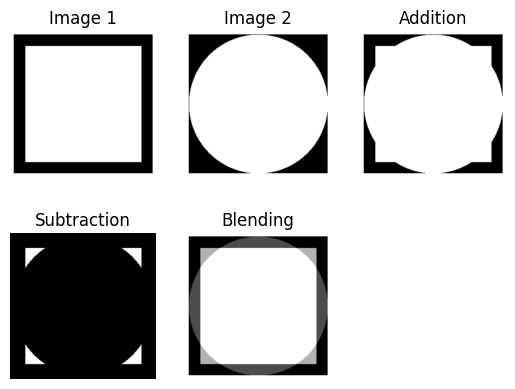

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("Upload Image 1")
f1 = files.upload()
print("Upload Image 2")
f2 = files.upload()

img1 = cv2.imread(list(f1.keys())[0])
img2 = cv2.imread(list(f2.keys())[0])

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

add = cv2.add(img1, img2)
sub = cv2.subtract(img1, img2)
blend = cv2.addWeighted(img1, 0.7, img2, 0.3, 0)

titles = ["Image 1", "Image 2", "Addition", "Subtraction", "Blending"]
images = [img1, img2, add, sub, blend]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i][:,:,::-1])
    plt.title(titles[i])
    plt.axis("off")

plt.show()

5. Apply logical AND, OR and XOR over two binary images.

Upload Image 1


Saving square.png to square (1).png
Upload Image 2


Saving circle.png to circle (1).png


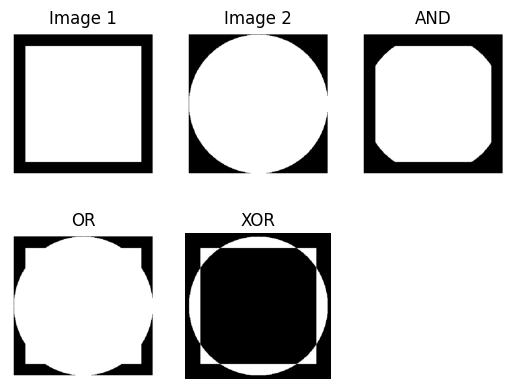

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("Upload Image 1")
f1 = files.upload()
print("Upload Image 2")
f2 = files.upload()

img1 = cv2.imread(list(f1.keys())[0], 0)
img2 = cv2.imread(list(f2.keys())[0], 0)

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

_, img1 = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)
_, img2 = cv2.threshold(img2, 127, 255, cv2.THRESH_BINARY)

a = cv2.bitwise_and(img1, img2)
o = cv2.bitwise_or(img1, img2)
x = cv2.bitwise_xor(img1, img2)

titles = ["Image 1", "Image 2", "AND", "OR", "XOR"]
images = [img1, img2, a, o, x]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.show()

6. Read a binary image and consider white pixels (value = 255) as background pixels and black pixels (value = 0) as foreground pixels. For any pixel at (x, y), the number of 4-neighbours is the number of pixels with the same colour as (x, y) in the 4-neighbourhood of (x, y), and the number of 8-neighbours is the number of pixels with the same colour as (x, y) in the 8-neighbourhood of (x, y). Compute the number of 4-neighbours and 8-neighbours for each pixel in the image. Do not use any library routine for computation.

In [ ]:
from google.colab import files
from PIL import Image

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = Image.open(image_path).convert('L')
w, h = img.size
px = img.load()

binimg = [[0]*w for _ in range(h)]
for y in range(h):
    for x in range(w):
        binimg[y][x] = 255 if px[x, y] >= 128 else 0

count4 = [[0]*w for _ in range(h)]
count8 = [[0]*w for _ in range(h)]

for y in range(h):
    for x in range(w):
        color = binimg[y][x]

        n4 = 0
        for dy, dx in [(-1,0), (1,0), (0,-1), (0,1)]:
            ny, nx = y+dy, x+dx
            if 0 <= ny < h and 0 <= nx < w and binimg[ny][nx] == color:
                n4 += 1

        n8 = 0
        for dy, dx in [(-1,-1),(-1,0),(-1,1),
                       (0,-1),        (0,1),
                       (1,-1),(1,0),(1,1)]:
            ny, nx = y+dy, x+dx
            if 0 <= ny < h and 0 <= nx < w and binimg[ny][nx] == color:
                n8 += 1

        count4[y][x] = n4
        count8[y][x] = n8

def print_grid(grid, width=3):
    for row in grid:
        print(' '.join(f'{v:{width}d}' for v in row))

print("Binarized image:")
print_grid(binimg)

print("\n4-neighbour counts:")
print_grid(count4, width=2)

print("\n8-neighbour counts:")
print_grid(count8, width=2)

Saving x.jpeg to x (2).jpeg
Binarized image:
255   0   0   0   0   0   0   0   0 255
  0 255   0   0   0   0   0   0 255   0
  0   0 255   0   0   0   0 255   0   0
  0   0   0 255   0   0 255   0   0   0
  0   0   0   0 255 255   0   0   0   0
  0   0   0   0 255 255   0   0   0   0
  0   0   0 255   0   0 255   0   0   0
  0   0 255   0   0   0   0 255   0   0
  0 255   0   0   0   0   0   0 255   0
255   0   0   0   0   0   0   0   0 255

4-neighbour counts:
 0  1  3  3  3  3  3  3  1  0
 1  0  2  4  4  4  4  2  0  1
 3  2  0  2  4  4  2  0  2  3
 3  4  2  0  2  2  0  2  4  3
 3  4  4  2  2  2  2  4  4  3
 3  4  4  2  2  2  2  4  4  3
 3  4  2  0  2  2  0  2  4  3
 3  2  0  2  4  4  2  0  2  3
 1  0  2  4  4  4  4  2  0  1
 0  1  3  3  3  3  3  3  1  0

8-neighbour counts:
 1  3  4  5  5  5  5  4  3  1
 3  2  6  7  8  8  7  6  2  3
 4  6  2  6  7  7  6  2  6  4
 5  7  6  2  5  5  2  6  7  5
 5  8  7  5  4  4  5  7  8  5
 5  8  7  5  4  4  5  7  8  5
 5  7  6  2  5  5  2  6  7  5
 4 

7. Read two pixel coordinates of an image and find the Euclidean and  Manhattan distances between them. (Do not use any library routine)

In [ ]:
x1 = int(input("Enter x1: "))
y1 = int(input("Enter y1: "))
x2 = int(input("Enter x2: "))
y2 = int(input("Enter y2: "))

dx = x2 - x1
dy = y2 - y1

euclidean = (dx*dx + dy*dy) ** 0.5
manhattan = abs(dx) + abs(dy)

print(f"\nPoint 1: ({x1}, {y1})")
print(f"Point 2: ({x2}, {y2})")
print(f"Euclidean Distance: {euclidean}")
print(f"Manhattan Distance: {manhattan}")

Enter x1: 1
Enter y1: 4
Enter x2: 8
Enter y2: 2

Point 1: (1, 4)
Point 2: (8, 2)
Euclidean Distance: 7.280109889280518
Manhattan Distance: 9


8. Find the negative of
* Binary image
* Gray scale image
* Colour image.

Saving stop.png to stop (1).png


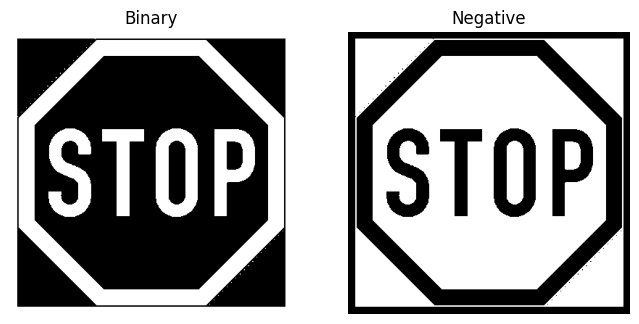

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(list(files.upload().keys())[0]).convert('L')
w, h = img.size
px = img.load()

binimg = [[255 if px[x,y]>=128 else 0 for x in range(w)] for y in range(h)]
neg = [[255-binimg[y][x] for x in range(w)] for y in range(h)]

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(binimg, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Binary'); ax[0].axis('off')
ax[1].imshow(neg, cmap='gray', vmin=0, vmax=255); ax[1].set_title('Negative'); ax[1].axis('off')
plt.show()

Saving b.png to b (1).png


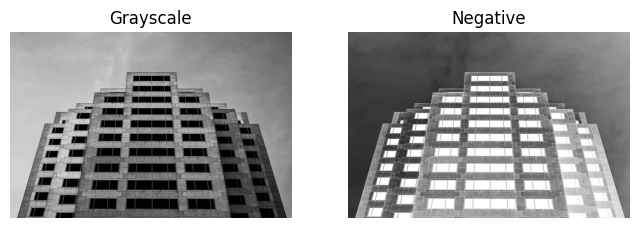

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(list(files.upload().keys())[0]).convert('L')
w, h = img.size
px = img.load()

neg = [[255-px[x,y] for x in range(w)] for y in range(h)]

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Grayscale'); ax[0].axis('off')
ax[1].imshow(neg, cmap='gray', vmin=0, vmax=255); ax[1].set_title('Negative'); ax[1].axis('off')
plt.show()

Saving view.png to view.png


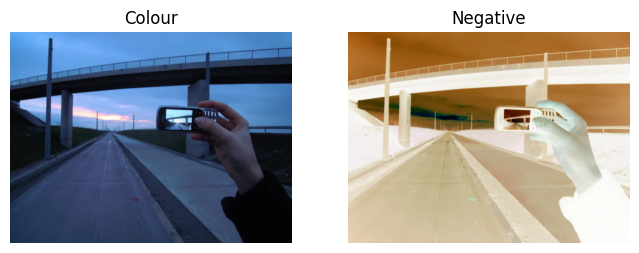

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(list(files.upload().keys())[0]).convert('RGB')
w, h = img.size
px = img.load()

neg_data = [(255-r, 255-g, 255-b) for y in range(h) for x in range(w) for r,g,b in [px[x,y]]]
neg_img = Image.new('RGB', (w,h)); neg_img.putdata(neg_data)

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(img); ax[0].set_title('Colour'); ax[0].axis('off')
ax[1].imshow(neg_img); ax[1].set_title('Negative'); ax[1].axis('off')
plt.show()

9. Apply log transform on a gray scale image.

Saving b.png to b (2).png


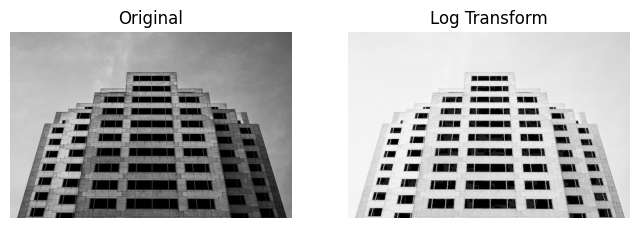

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import math

img = Image.open(list(files.upload().keys())[0]).convert('L')
w, h = img.size
px = img.load()

c = 255 / math.log(1 + 255)

out = [[int(c * math.log(1 + px[x,y])) for x in range(w)] for y in range(h)]

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(out, cmap='gray', vmin=0, vmax=255); ax[1].set_title('Log Transform'); ax[1].axis('off')
plt.show()

10. Apply gamma correction over grayscle and color images. (Test with gamma = 0.2, 0.5, 1.5, 2, 3)

Saving b.png to b (3).png


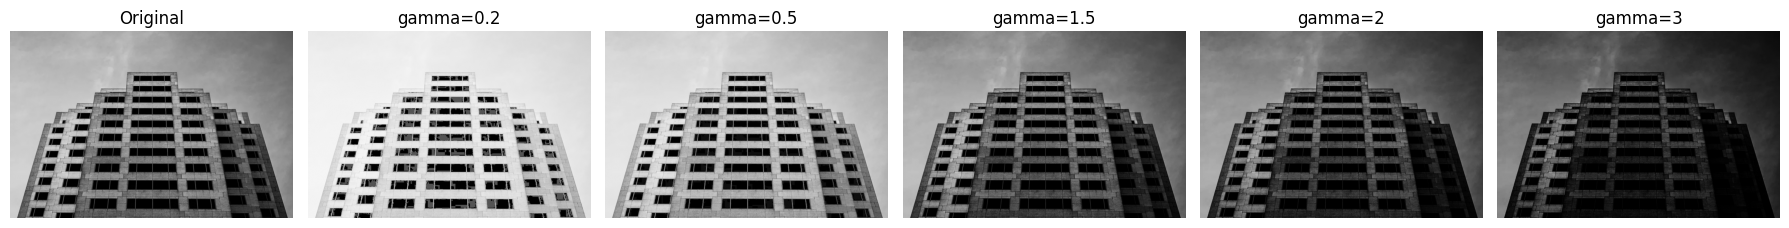

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(list(files.upload().keys())[0]).convert('L')
w, h = img.size
px = img.load()

gammas = [0.2, 0.5, 1.5, 2, 3]

fig, ax = plt.subplots(1, len(gammas)+1, figsize=(18,4))
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')

for i, g in enumerate(gammas):
    out = [[int(255 * (px[x,y]/255) ** g) for x in range(w)] for y in range(h)]
    ax[i+1].imshow(out, cmap='gray', vmin=0, vmax=255)
    ax[i+1].set_title(f'gamma={g}')
    ax[i+1].axis('off')

plt.tight_layout()
plt.show()

Saving view.png to view (1).png


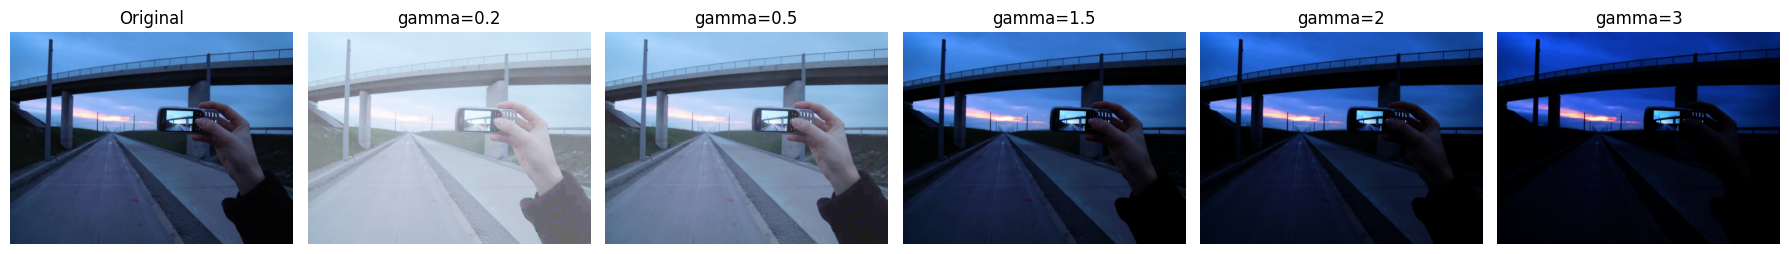

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(list(files.upload().keys())[0]).convert('RGB')
w, h = img.size
px = img.load()

gammas = [0.2, 0.5, 1.5, 2, 3]

fig, ax = plt.subplots(1, len(gammas)+1, figsize=(18,4))
ax[0].imshow(img); ax[0].set_title('Original'); ax[0].axis('off')

for i, g in enumerate(gammas):
    data = []
    for y in range(h):
        for x in range(w):
            r, gr, b = px[x,y]
            data.append((
                int(255*(r/255)**g),
                int(255*(gr/255)**g),
                int(255*(b/255)**g)
            ))
    out_img = Image.new('RGB', (w,h))
    out_img.putdata(data)
    ax[i+1].imshow(out_img)
    ax[i+1].set_title(f'gamma={g}')
    ax[i+1].axis('off')

plt.tight_layout()
plt.show()

11. Write a program to apply histogram equalization on a grayscale image. Show the image and corresponding histogram before and after applying the equalization.

Saving b.png to b (4).png


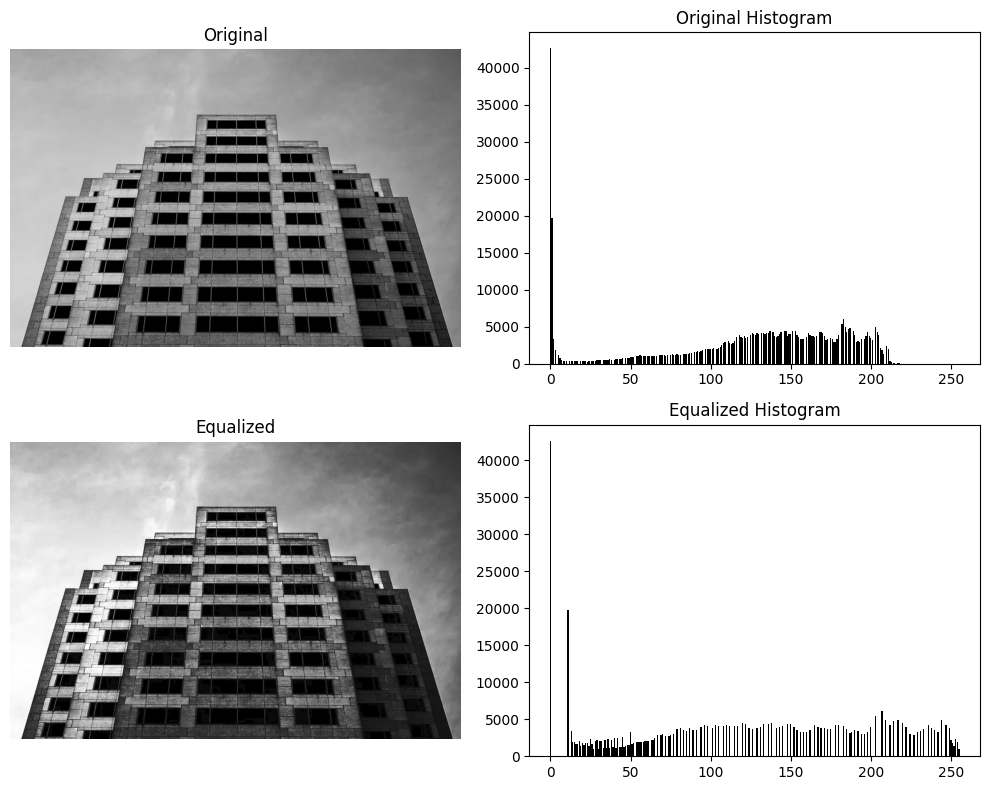

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(list(files.upload().keys())[0]).convert('L')
w, h = img.size
px = img.load()
total = w * h

hist = [0]*256
for y in range(h):
    for x in range(w):
        hist[px[x,y]] += 1

cdf = [sum(hist[:i+1]) for i in range(256)]
cdf_min = next(v for v in cdf if v > 0)
eq_map = [round((c - cdf_min) / (total - cdf_min) * 255) for c in cdf]

out = [[eq_map[px[x,y]] for x in range(w)] for y in range(h)]
out_img = Image.new('L', (w,h)); out_img.putdata([out[y][x] for y in range(h) for x in range(w)])

hist_out = [0]*256
for row in out:
    for v in row:
        hist_out[v] += 1

fig, ax = plt.subplots(2, 2, figsize=(10,8))
ax[0,0].imshow(img, cmap='gray', vmin=0, vmax=255); ax[0,0].set_title('Original'); ax[0,0].axis('off')
ax[0,1].bar(range(256), hist, color='black'); ax[0,1].set_title('Original Histogram')
ax[1,0].imshow(out_img, cmap='gray', vmin=0, vmax=255); ax[1,0].set_title('Equalized'); ax[1,0].axis('off')
ax[1,1].bar(range(256), hist_out, color='black'); ax[1,1].set_title('Equalized Histogram')
plt.tight_layout()
plt.show()

12. Write a program to apply histogram equalization on a colour image. Show the image and corresponding histogram before and after applying the equalization.[Convert RGB image to HSV image, apply equalization over the 'V' channel and convert HSV image back to RGB and and display]


Saving view.png to view (2).png


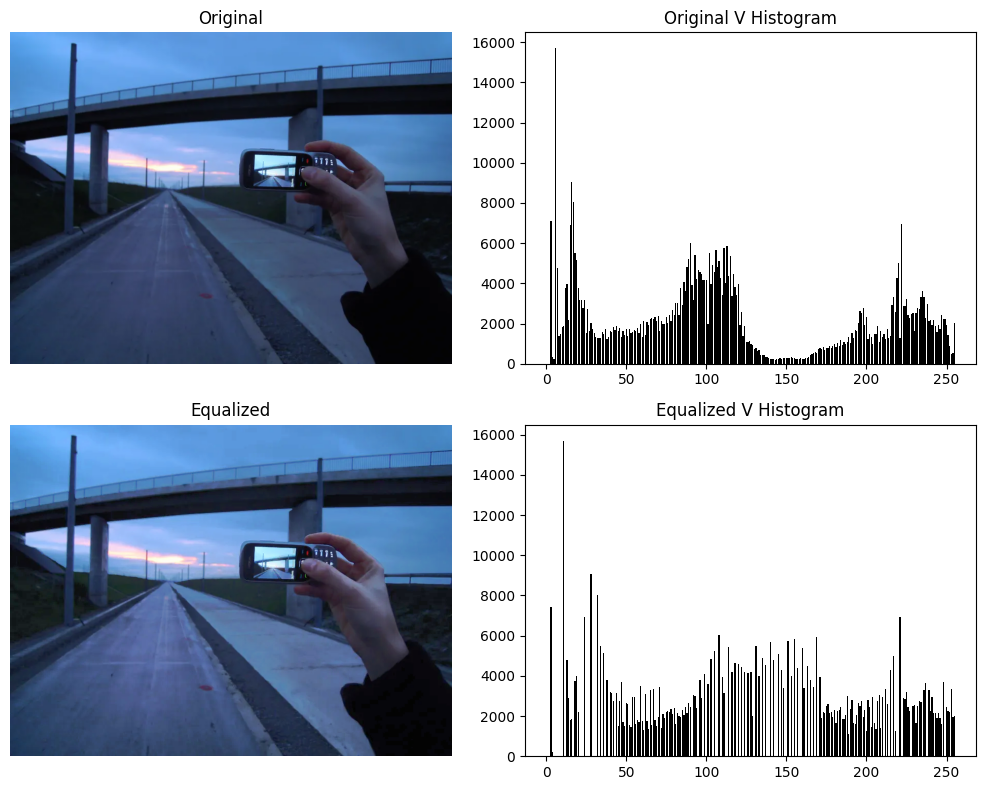

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(list(files.upload().keys())[0]).convert('RGB')
hsv = img.convert('HSV')
w, h = hsv.size
px = hsv.load()
total = w * h

hist = [0]*256
for y in range(h):
    for x in range(w):
        hist[px[x,y][2]] += 1

cdf = [sum(hist[:i+1]) for i in range(256)]
cdf_min = next(v for v in cdf if v > 0)
eq_map = [round((c - cdf_min) / (total - cdf_min) * 255) for c in cdf]

new_hsv = Image.new('HSV', (w,h))
data = []
for y in range(h):
    for x in range(w):
        hh, s, v = px[x,y]
        data.append((hh, s, eq_map[v]))
new_hsv.putdata(data)

out_img = new_hsv.convert('RGB')

hist_out = [0]*256
for hh, s, v in data:
    hist_out[v] += 1

fig, ax = plt.subplots(2, 2, figsize=(10,8))
ax[0,0].imshow(img); ax[0,0].set_title('Original'); ax[0,0].axis('off')
ax[0,1].bar(range(256), hist, color='black'); ax[0,1].set_title('Original V Histogram')
ax[1,0].imshow(out_img); ax[1,0].set_title('Equalized'); ax[1,0].axis('off')
ax[1,1].bar(range(256), hist_out, color='black'); ax[1,1].set_title('Equalized V Histogram')
plt.tight_layout()
plt.show()